In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

import celldega as dega
import pandas as pd
import geopandas as gpd

print(dega.__version__)

env: ANYWIDGET_HMR=1


/Users/jishar/Documents/celldega/dega/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/jishar/Documents/celldega/dega/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/jishar/Documents/celldega/dega/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_red

0.14.2


In [2]:
sample = 'Xenium_Prime_Human_Skin_FFPE_outs'
data_dir = f'data/xenium_data/'
path_landscape_files=f'data/landscape_files/{sample}_06_OCT_2025'

In [3]:
# landscape = dega.viz.Landscape(
#     technology='Xenium',
#     base_url = f"http://localhost:{dega.viz.get_local_server()}/{path_landscape_files}",
#     nbhd_edit = True
# )

# landscape

In [4]:
# ROI_gdf = landscape.nbhd
# ROI_gdf.to_parquet(f"{path_landscape_files}/ROI_gdf.parquet")

In [5]:
ROI_gdf = gpd.read_parquet(f"{path_landscape_files}/ROI_gdf.parquet")

In [6]:
ROI_gdf

,geometry,name,cat,color,area
0,"POLYGON ((553.695 1832.795, 2112.041 1867.581,...",dermis,dermis,#7bf18b,9.668889e+07


In [7]:
import numpy as np
import geopandas as gpd
from shapely.ops import transform


def load_transform_matrix(path):
    # match transcript code exactly
    M = np.loadtxt(path)
    if M.shape != (3, 3):
        raise ValueError(f"Expected 3x3 matrix, got {M.shape}")
    return M


def make_transcript_style_transformer(M, image_scale=1):
    """
    Replicate the transcript pipeline exactly:
      transformed = M @ [x, y, 1]^T
      keep first two coords only
      multiply by image_scale
    No division by w.
    """
    def _transform(x, y, z=None):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        pts = np.vstack([x, y, np.ones_like(x)])
        out = M @ pts

        x_t = out[0] * image_scale
        y_t = out[1] * image_scale

        if z is None:
            return x_t, y_t
        return x_t, y_t, z

    return _transform


def transform_gdf_micron_to_pixel(gdf, matrix_csv_path, image_scale=1):
    M = load_transform_matrix(matrix_csv_path)
    tfm = make_transcript_style_transformer(M, image_scale=image_scale)

    out = gdf.copy()
    out["geometry"] = out.geometry.apply(
        lambda geom: transform(tfm, geom) if geom is not None else None
    )
    return out

In [8]:
polygon_gdf_px = transform_gdf_micron_to_pixel(
    ROI_gdf,
    f"{path_landscape_files}/micron_to_image_transform.csv",
    image_scale=1,   # or whatever you used when creating transcript tiles
)

print("before:", ROI_gdf.geometry.iloc[0].bounds)
print("after: ", polygon_gdf_px.geometry.iloc[0].bounds)

before: (368.75850468473834, 1832.7945150086534, 2933.04024681672, 4270.710123099385)
after:  (1735.3340095428257, 8624.914717877951, 13802.54130277036, 20097.45789551118)


<Axes: >

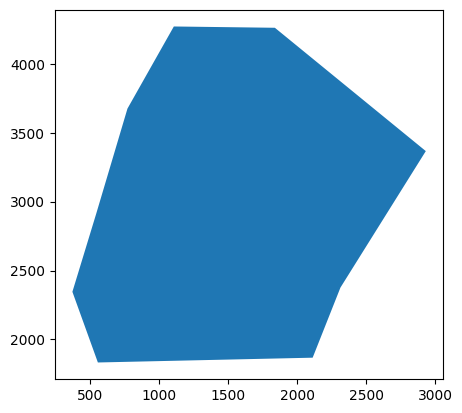

In [9]:
ROI_gdf.plot()

<Axes: >

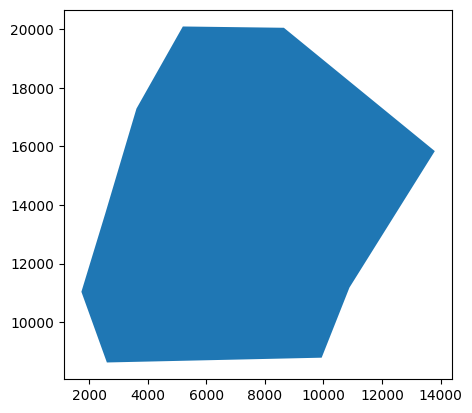

In [10]:
polygon_gdf_px.plot()

In [11]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import points


def get_candidate_tile_files_from_gdf_lenient(
    polygon_gdf,
    polygon_idx=0,
    tile_dir="transcript_tiles",
    tile_size=250,
    x_min=0,
    y_min=0,
):
    """
    Lenient file selection:
    use the polygon bbox and include every tile in that tile-index rectangle.
    This may include extra files, but should not miss relevant transcripts.
    """
    geom = polygon_gdf.geometry.iloc[polygon_idx]
    minx, miny, maxx, maxy = geom.bounds

    i_min = max(0, math.floor((minx - x_min) / tile_size))
    i_max = max(0, math.floor((maxx - x_min) / tile_size))
    j_min = max(0, math.floor((miny - y_min) / tile_size))
    j_max = max(0, math.floor((maxy - y_min) / tile_size))

    files = []
    for i in range(i_min, i_max + 1):
        for j in range(j_min, j_max + 1):
            f = Path(tile_dir) / f"transcripts_tile_{i}_{j}.parquet"
            if f.exists():
                files.append(f)

    return files


def load_transcripts_from_candidate_files(files):
    """
    Read transcript parquet tiles and unpack geometry=[x, y] into x/y columns.
    """
    dfs = []

    for f in files:
        df = pd.read_parquet(f)
        if df.empty:
            continue

        if "geometry" not in df.columns:
            raise ValueError(f"{f} does not contain a 'geometry' column")

        geom_vals = df["geometry"].tolist()
        xy = pd.DataFrame(geom_vals, columns=["x", "y"], index=df.index)

        out = pd.concat([df, xy], axis=1)
        dfs.append(out)

    if not dfs:
        return pd.DataFrame(columns=["x", "y"])

    trx = pd.concat(dfs, ignore_index=True)

    # Make sure x/y are numeric
    trx["x"] = pd.to_numeric(trx["x"], errors="coerce")
    trx["y"] = pd.to_numeric(trx["y"], errors="coerce")
    trx = trx.dropna(subset=["x", "y"]).reset_index(drop=True)

    return trx


def transcripts_within_polygon_from_gdf_lenient(
    polygon_gdf,
    polygon_idx=0,
    tile_dir="transcript_tiles",
    tile_size=250,
    x_min=0,
    y_min=0,
    predicate="covers",   # covers includes boundary points
    return_candidate_files=False,
):
    """
    Load transcripts from all bbox-overlapping tile files, then keep only those
    whose points fall inside the chosen polygon.
    """
    geom = polygon_gdf.geometry.iloc[polygon_idx]
    minx, miny, maxx, maxy = geom.bounds

    files = get_candidate_tile_files_from_gdf_lenient(
        polygon_gdf=polygon_gdf,
        polygon_idx=polygon_idx,
        tile_dir=tile_dir,
        tile_size=tile_size,
        x_min=x_min,
        y_min=y_min,
    )

    trx = load_transcripts_from_candidate_files(files)

    if trx.empty:
        empty = gpd.GeoDataFrame(trx.copy(), geometry=gpd.GeoSeries([], crs=polygon_gdf.crs), crs=polygon_gdf.crs)
        return (empty, files) if return_candidate_files else empty

    # Cheap bbox prefilter first
    trx = trx[
        (trx["x"] >= minx) & (trx["x"] <= maxx) &
        (trx["y"] >= miny) & (trx["y"] <= maxy)
    ].copy()

    if trx.empty:
        empty = gpd.GeoDataFrame(trx.copy(), geometry=gpd.GeoSeries([], crs=polygon_gdf.crs), crs=polygon_gdf.crs)
        return (empty, files) if return_candidate_files else empty

    pts = gpd.GeoSeries(
        points(trx["x"].to_numpy(), trx["y"].to_numpy()),
        index=trx.index,
        crs=polygon_gdf.crs,
    )

    if predicate == "contains":
        mask = pts.within(geom)
    elif predicate == "intersects":
        mask = pts.intersects(geom)
    elif predicate == "within":
        mask = pts.within(geom)
    else:
        # default: include boundary points
        mask = pts.apply(geom.covers)

    out = trx.loc[mask].copy()
    out = gpd.GeoDataFrame(out, geometry=pts.loc[mask], crs=polygon_gdf.crs)

    return (out, files) if return_candidate_files else out

In [12]:
hits, candidate_files = transcripts_within_polygon_from_gdf_lenient(
    polygon_gdf=polygon_gdf_px,   # transformed polygon gdf
    polygon_idx=0,
    tile_dir=f"{path_landscape_files}/transcript_tiles",
    tile_size=250,
    x_min=0,
    y_min=0,
    predicate="covers",
    return_candidate_files=True,
)

print("candidate files:", len(candidate_files))
print("hits:", len(hits))
print(hits.head())

candidate files: 1882
hits: 6129511
       name                    geometry        x         y
75368    57  POINT (1748.600 11003.460)  1748.60  11003.46
75427    83  POINT (1749.120 11050.880)  1749.12  11050.88
75481   103  POINT (1747.210 11048.900)  1747.21  11048.90
75578   152  POINT (1742.430 11018.820)  1742.43  11018.82
75658   161  POINT (1747.350 11016.100)  1747.35  11016.10


<Axes: >

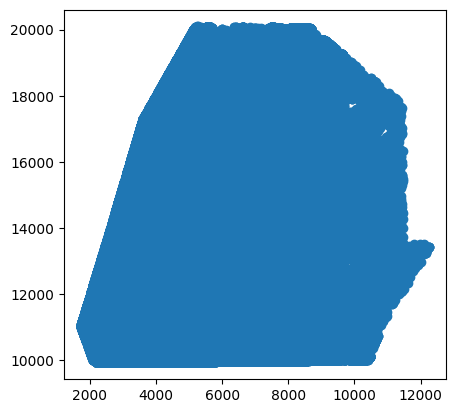

In [13]:
hits.plot()

In [14]:
gene_str_to_int_mapping = dega.pre.trx_tile._get_name_mapping(
            path_landscape_files.replace("/transcript_tiles", ""),
            layer="transcript",
        )

In [15]:
int_to_gene = {v: k for k, v in gene_str_to_int_mapping.items()}

hits["gene"] = hits["name"].map(int_to_gene)
hits

,name,geometry,x,y,gene
75368,57,POINT (1748.600 11003.460),1748.60,11003.46,ACTN4
75427,83,POINT (1749.120 11050.880),1749.12,11050.88,ADD1
75481,103,POINT (1747.210 11048.900),1747.21,11048.90,ADNP
75578,152,POINT (1742.430 11018.820),1742.43,11018.82,AKT2
75658,161,POINT (1747.350 11016.100),1747.35,11016.10,ALDOA
...,...,...,...,...,...
9068732,9973,POINT (12246.910 13433.090),12246.91,13433.09,ZMPSTE24
9068733,2774,POINT (12105.070 13503.820),12105.07,13503.82,LDHA
9068734,9322,POINT (12106.180 13516.760),12106.18,13516.76,UnassignedCodeword_7651
9145995,1917,POINT (12251.540 13433.900),12251.54,13433.90,FOXD2


In [16]:
hits.reset_index(inplace=True)
hits.rename(columns={"index":"transcript_id"}, inplace=True)
hits

,transcript_id,name,geometry,x,y,gene
0,75368,57,POINT (1748.600 11003.460),1748.60,11003.46,ACTN4
1,75427,83,POINT (1749.120 11050.880),1749.12,11050.88,ADD1
2,75481,103,POINT (1747.210 11048.900),1747.21,11048.90,ADNP
3,75578,152,POINT (1742.430 11018.820),1742.43,11018.82,AKT2
4,75658,161,POINT (1747.350 11016.100),1747.35,11016.10,ALDOA
...,...,...,...,...,...,...
6129506,9068732,9973,POINT (12246.910 13433.090),12246.91,13433.09,ZMPSTE24
6129507,9068733,2774,POINT (12105.070 13503.820),12105.07,13503.82,LDHA
6129508,9068734,9322,POINT (12106.180 13516.760),12106.18,13516.76,UnassignedCodeword_7651
6129509,9145995,1917,POINT (12251.540 13433.900),12251.54,13433.90,FOXD2


In [17]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon


def _cell_geom_to_polygon(val):
    if val is None:
        return None

    if isinstance(val, Polygon):
        return val

    try:
        arr = np.asarray(val, dtype=object)

        # unwrap nested single-element wrappers
        while isinstance(arr, np.ndarray) and arr.ndim > 0 and len(arr) == 1:
            arr = arr[0]

        coords = np.array([np.asarray(pt, dtype=float) for pt in arr], dtype=float)

        if coords.ndim != 2 or coords.shape[1] != 2 or len(coords) < 3:
            return None

        poly = Polygon(coords)

        if poly.is_empty:
            return None

        if not poly.is_valid:
            poly = poly.buffer(0)

        return poly if not poly.is_empty else None

    except Exception:
        return None


def get_candidate_cell_tile_files_lenient(
    roi_gdf,
    roi_idx=0,
    cell_tile_dir="cell_segmentation",
    tile_size=250,
    x_min=0,
    y_min=0,
    tile_margin=2,
):
    geom = roi_gdf.geometry.iloc[roi_idx]
    minx, miny, maxx, maxy = geom.bounds

    i_min = max(0, math.floor((minx - x_min) / tile_size) - tile_margin)
    i_max = max(0, math.floor((maxx - x_min) / tile_size) + tile_margin)
    j_min = max(0, math.floor((miny - y_min) / tile_size) - tile_margin)
    j_max = max(0, math.floor((maxy - y_min) / tile_size) + tile_margin)

    files = []
    for i in range(i_min, i_max + 1):
        for j in range(j_min, j_max + 1):
            f = Path(cell_tile_dir) / f"cell_tile_{i}_{j}.parquet"
            if f.exists():
                files.append(f)

    return files


def load_cells_from_candidate_files(files, crs=None):
    dfs = []

    for f in files:
        df = pd.read_parquet(f)
        if df.empty:
            continue

        if "GEOMETRY" not in df.columns:
            raise ValueError(f"{f} does not contain a GEOMETRY column")

        df = df.copy()
        df["geometry"] = df["GEOMETRY"].apply(_cell_geom_to_polygon)
        df = df[df["geometry"].notna()].copy()

        if not df.empty:
            dfs.append(df)

    if not dfs:
        return gpd.GeoDataFrame(
            pd.DataFrame(columns=["name", "GEOMETRY", "geometry"]),
            geometry="geometry",
            crs=crs,
        )

    out = pd.concat(dfs, ignore_index=True)
    return gpd.GeoDataFrame(out, geometry="geometry", crs=crs)


def cells_in_roi_from_gdf(
    roi_gdf,
    roi_idx=0,
    cell_tile_dir="cell_segmentation",
    tile_size=250,
    x_min=0,
    y_min=0,
    tile_margin=2,
    predicate="intersects",
    return_candidate_files=False,
):
    roi_geom = roi_gdf.geometry.iloc[roi_idx]

    files = get_candidate_cell_tile_files_lenient(
        roi_gdf=roi_gdf,
        roi_idx=roi_idx,
        cell_tile_dir=cell_tile_dir,
        tile_size=tile_size,
        x_min=x_min,
        y_min=y_min,
        tile_margin=tile_margin,
    )

    cells = load_cells_from_candidate_files(files, crs=roi_gdf.crs)
    if cells.empty:
        return (cells, files) if return_candidate_files else cells

    minx, miny, maxx, maxy = roi_geom.bounds
    bounds = cells.geometry.bounds
    bbox_mask = (
        (bounds["maxx"] >= minx) &
        (bounds["minx"] <= maxx) &
        (bounds["maxy"] >= miny) &
        (bounds["miny"] <= maxy)
    )
    cells = cells.loc[bbox_mask].copy()

    if cells.empty:
        return (cells, files) if return_candidate_files else cells

    if predicate == "within":
        mask = cells.geometry.within(roi_geom)
    elif predicate == "contains":
        mask = cells.geometry.apply(roi_geom.contains)
    elif predicate == "centroid_within":
        mask = cells.geometry.centroid.within(roi_geom)
    else:
        mask = cells.geometry.intersects(roi_geom)

    hits = cells.loc[mask].copy()
    return (hits, files) if return_candidate_files else hits

In [18]:
cell_hits, cell_files = cells_in_roi_from_gdf(
    roi_gdf=polygon_gdf_px,
    roi_idx=0,
    cell_tile_dir=f"{path_landscape_files}/cell_segmentation",
    tile_size=250,
    x_min=0,
    y_min=0,
    tile_margin=2,
    predicate="intersects",
    return_candidate_files=True,
)

print("candidate files:", len(cell_files))
print("cell hits:", len(cell_hits))
print(cell_hits.head())

candidate files: 1459
cell hits: 15792
                                              GEOMETRY  name  \
479  [[[1637.0, 10922.0], [1632.0, 10925.0], [1634....   311   
480  [[[1754.0, 10891.0], [1733.0, 10901.0], [1723....   314   
496  [[[1639.0, 11005.0], [1634.0, 11007.0], [1628....   259   
498  [[[1685.0, 11001.0], [1677.0, 11002.0], [1669....   268   
500  [[[1676.0, 10970.0], [1670.0, 10974.0], [1670....   312   

                                              geometry  
479  POLYGON ((1637.000 10922.000, 1632.000 10925.0...  
480  POLYGON ((1754.000 10891.000, 1733.000 10901.0...  
496  POLYGON ((1639.000 11005.000, 1634.000 11007.0...  
498  POLYGON ((1685.000 11001.000, 1677.000 11002.0...  
500  POLYGON ((1676.000 10970.000, 1670.000 10974.0...  


In [19]:
cell_str_to_int_mapping = dega.pre.boundary_tile._get_name_mapping(
            path_landscape_files.replace("/cell_segmentation", ""),
            layer="boundary",
        )

int_to_cell = {v: k for k, v in cell_str_to_int_mapping.items()}

cell_hits["cell_id_str"] = cell_hits["name"].map(int_to_cell)
cell_hits.head()

,GEOMETRY,name,geometry,cell_id_str
479,"[[[1637.0, 10922.0], [1632.0, 10925.0], [1634....",311,"POLYGON ((1637.000 10922.000, 1632.000 10925.0...",aajgonna-1
480,"[[[1754.0, 10891.0], [1733.0, 10901.0], [1723....",314,"POLYGON ((1754.000 10891.000, 1733.000 10901.0...",aajikoig-1
496,"[[[1639.0, 11005.0], [1634.0, 11007.0], [1628....",259,"POLYGON ((1639.000 11005.000, 1634.000 11007.0...",aaholcad-1
498,"[[[1685.0, 11001.0], [1677.0, 11002.0], [1669....",268,"POLYGON ((1685.000 11001.000, 1677.000 11002.0...",aaidpdeb-1
500,"[[[1676.0, 10970.0], [1670.0, 10974.0], [1670....",312,"POLYGON ((1676.000 10970.000, 1670.000 10974.0...",aajhaeep-1


<Axes: >

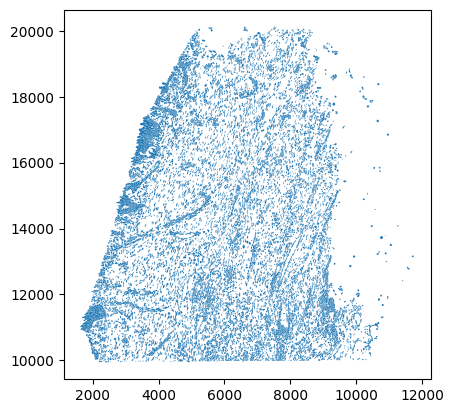

In [23]:
cell_hits.plot()

In [20]:
import geopandas as gpd
from shapely import points

trx_hits_gdf = gpd.GeoDataFrame(
    hits.copy(),
    geometry=points(hits["x"].to_numpy(), hits["y"].to_numpy()),
    crs=cell_hits.crs,
)

In [21]:
trx_in_cells = gpd.sjoin(
    trx_hits_gdf,
    cell_hits[["cell_id_str", "geometry"]],
    how="left",
    predicate="within",   # or "intersects"
)

In [22]:
trx_in_cells.head()

,transcript_id,name,geometry,x,y,gene,index_right,cell_id_str
0,75368,57,POINT (1748.600 11003.460),1748.60,11003.46,ACTN4,500.0,aajhaeep-1
1,75427,83,POINT (1749.120 11050.880),1749.12,11050.88,ADD1,819.0,aahoobof-1
2,75481,103,POINT (1747.210 11048.900),1747.21,11048.90,ADNP,819.0,aahoobof-1
3,75578,152,POINT (1742.430 11018.820),1742.43,11018.82,AKT2,498.0,aaidpdeb-1
4,75658,161,POINT (1747.350 11016.100),1747.35,11016.10,ALDOA,498.0,aaidpdeb-1


<Axes: >

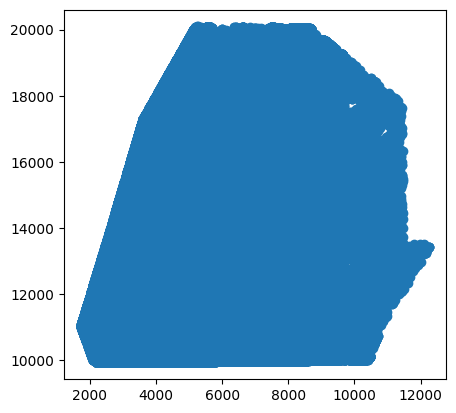

In [24]:
trx_in_cells.plot()

In [27]:
import numpy as np
import pandas as pd

def summarize_roi_metrics(
    trx_hits,
    cell_hits,
    trx_in_cells,
    gene_col="gene",          # or "name" if still using gene int ids
    cell_id_col="cell_id_str" # or "cell_id_int"
):
    # Basic counts
    total_transcripts = len(trx_hits)
    total_cells = len(cell_hits)

    assigned_mask = trx_in_cells[cell_id_col].notna()
    assigned_transcripts = int(assigned_mask.sum())
    unassigned_transcripts = int((~assigned_mask).sum())

    proportion_assigned = (
        assigned_transcripts / total_transcripts if total_transcripts > 0 else np.nan
    )

    # ROI area
    roi_area = cell_hits.unary_union.envelope.area if total_cells > 0 else np.nan

    # Better: actual polygon area from ROI if available outside this function
    # pass it in separately if you want exact ROI area

    # Cell areas
    if total_cells > 0:
        cell_areas = cell_hits.geometry.area
        avg_cell_area = float(cell_areas.mean())
        median_cell_area = float(cell_areas.median())
        min_cell_area = float(cell_areas.min())
        max_cell_area = float(cell_areas.max())
    else:
        avg_cell_area = median_cell_area = min_cell_area = max_cell_area = np.nan

    # Transcripts per cell
    if assigned_transcripts > 0:
        trx_per_cell = (
            trx_in_cells.loc[assigned_mask]
            .groupby(cell_id_col)
            .size()
        )
        avg_transcripts_per_cell = float(trx_per_cell.mean())
        median_transcripts_per_cell = float(trx_per_cell.median())
        max_transcripts_per_cell = int(trx_per_cell.max())
    else:
        avg_transcripts_per_cell = median_transcripts_per_cell = np.nan
        max_transcripts_per_cell = np.nan

    # Unique genes detected
    if gene_col in trx_hits.columns and total_transcripts > 0:
        n_genes_detected = int(trx_hits[gene_col].nunique())
    else:
        n_genes_detected = np.nan

    metrics = pd.Series({
        "total_transcripts": total_transcripts,
        "assigned_transcripts": assigned_transcripts,
        "unassigned_transcripts": unassigned_transcripts,
        "proportion_transcripts_assigned": proportion_assigned,
        "total_cells": total_cells,
        "avg_cell_area": avg_cell_area,
        "median_cell_area": median_cell_area,
        "min_cell_area": min_cell_area,
        "max_cell_area": max_cell_area,
        "avg_transcripts_per_cell": avg_transcripts_per_cell,
        "median_transcripts_per_cell": median_transcripts_per_cell,
        "max_transcripts_per_cell": max_transcripts_per_cell,
        "n_genes_detected": n_genes_detected,
    })

    return metrics

def add_roi_density_metrics(metrics, roi_gdf, roi_idx=0):
    roi_area = roi_gdf.geometry.iloc[roi_idx].area

    metrics = metrics.copy()
    metrics["roi_area"] = roi_area
    metrics["transcript_density"] = (
        metrics["total_transcripts"] / roi_area if roi_area > 0 else np.nan
    )
    metrics["cell_density"] = (
        metrics["total_cells"] / roi_area if roi_area > 0 else np.nan
    )
    return metrics

In [26]:
roi_metrics = summarize_roi_metrics(
    trx_hits=trx_hits_gdf,      # or trx_hits if same rows
    cell_hits=cell_hits,
    trx_in_cells=trx_in_cells,
    gene_col="gene",            # switch to "name" if needed
    cell_id_col="cell_id_str",
)

print(roi_metrics)

total_transcripts                  6.129511e+06
assigned_transcripts               4.264783e+06
unassigned_transcripts             1.864819e+06
proportion_transcripts_assigned    6.957787e-01
total_cells                        1.579200e+04
avg_cell_area                      1.218729e+03
median_cell_area                   1.072000e+03
min_cell_area                      4.650000e+01
max_cell_area                      1.152050e+04
avg_transcripts_per_cell           2.707799e+02
median_transcripts_per_cell        2.080000e+02
max_transcripts_per_cell           3.391000e+03
n_genes_detected                   9.138000e+03
dtype: float64


In [28]:
roi_metrics = add_roi_density_metrics(roi_metrics, polygon_gdf_px, roi_idx=0)
print(roi_metrics)

total_transcripts                  6.129511e+06
assigned_transcripts               4.264783e+06
unassigned_transcripts             1.864819e+06
proportion_transcripts_assigned    6.957787e-01
total_cells                        1.579200e+04
avg_cell_area                      1.218729e+03
median_cell_area                   1.072000e+03
min_cell_area                      4.650000e+01
max_cell_area                      1.152050e+04
avg_transcripts_per_cell           2.707799e+02
median_transcripts_per_cell        2.080000e+02
max_transcripts_per_cell           3.391000e+03
n_genes_detected                   9.138000e+03
roi_area                           9.668889e+07
transcript_density                 6.339416e-02
cell_density                       1.633280e-04
dtype: float64


In [29]:
def extra_roi_metrics(trx_in_cells, cell_hits, gene_col="gene", cell_id_col="cell_id_str"):
    assigned = trx_in_cells[trx_in_cells[cell_id_col].notna()].copy()

    # cells with at least one transcript
    n_cells_with_transcripts = assigned[cell_id_col].nunique()

    # fraction of ROI cells that got at least one transcript
    frac_cells_with_transcripts = (
        n_cells_with_transcripts / len(cell_hits) if len(cell_hits) > 0 else np.nan
    )

    # genes per cell
    if len(assigned) > 0 and gene_col in assigned.columns:
        genes_per_cell = assigned.groupby(cell_id_col)[gene_col].nunique()
        avg_genes_per_cell = float(genes_per_cell.mean())
        median_genes_per_cell = float(genes_per_cell.median())
    else:
        avg_genes_per_cell = np.nan
        median_genes_per_cell = np.nan

    return pd.Series({
        "cells_with_at_least_one_transcript": n_cells_with_transcripts,
        "fraction_cells_with_at_least_one_transcript": frac_cells_with_transcripts,
        "avg_genes_per_cell": avg_genes_per_cell,
        "median_genes_per_cell": median_genes_per_cell,
    })

In [30]:
roi_metrics = pd.concat([
    roi_metrics,
    extra_roi_metrics(
        trx_in_cells,
        cell_hits,
        gene_col="gene",
        cell_id_col="cell_id_str",
    )
])

print(roi_metrics)

total_transcripts                              6.129511e+06
assigned_transcripts                           4.264783e+06
unassigned_transcripts                         1.864819e+06
proportion_transcripts_assigned                6.957787e-01
total_cells                                    1.579200e+04
avg_cell_area                                  1.218729e+03
median_cell_area                               1.072000e+03
min_cell_area                                  4.650000e+01
max_cell_area                                  1.152050e+04
avg_transcripts_per_cell                       2.707799e+02
median_transcripts_per_cell                    2.080000e+02
max_transcripts_per_cell                       3.391000e+03
n_genes_detected                               9.138000e+03
roi_area                                       9.668889e+07
transcript_density                             6.339416e-02
cell_density                                   1.633280e-04
cells_with_at_least_one_transcript      

In [31]:
roi_metrics.to_frame(name="value")

,value
total_transcripts,6.129511e+06
assigned_transcripts,4.264783e+06
unassigned_transcripts,1.864819e+06
proportion_transcripts_assigned,6.957787e-01
total_cells,1.579200e+04
avg_cell_area,1.218729e+03
median_cell_area,1.072000e+03
min_cell_area,4.650000e+01
max_cell_area,1.152050e+04
avg_transcripts_per_cell,2.707799e+02


/Users/jishar/Documents/celldega/dega/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


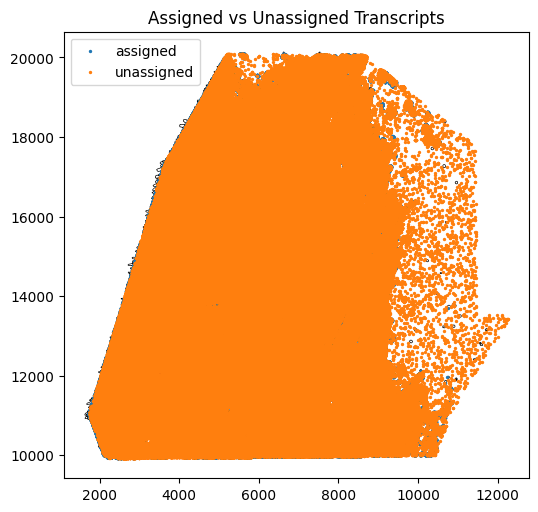

In [33]:
import matplotlib.pyplot as plt

assigned = trx_in_cells[trx_in_cells["cell_id_str"].notna()]
unassigned = trx_in_cells[trx_in_cells["cell_id_str"].isna()]

fig, ax = plt.subplots(figsize=(6, 6))

cell_hits.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

assigned.plot(ax=ax, markersize=2, label="assigned")
unassigned.plot(ax=ax, markersize=2, label="unassigned")

ax.legend()
ax.set_title("Assigned vs Unassigned Transcripts")
plt.show()

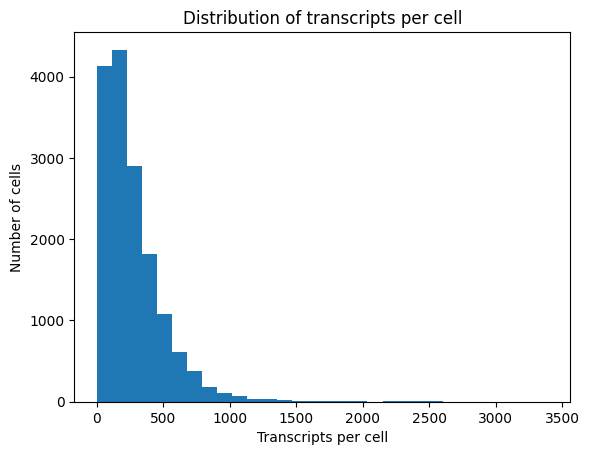

In [34]:
import matplotlib.pyplot as plt

trx_per_cell = (
    trx_in_cells.dropna(subset=["cell_id_str"])
    .groupby("cell_id_str")
    .size()
)

plt.figure()
plt.hist(trx_per_cell, bins=30)
plt.xlabel("Transcripts per cell")
plt.ylabel("Number of cells")
plt.title("Distribution of transcripts per cell")
plt.show()

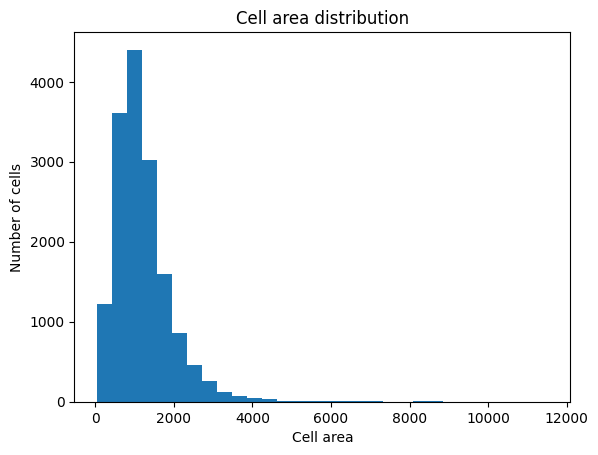

In [35]:
cell_areas = cell_hits.geometry.area

plt.figure()
plt.hist(cell_areas, bins=30)
plt.xlabel("Cell area")
plt.ylabel("Number of cells")
plt.title("Cell area distribution")
plt.show()

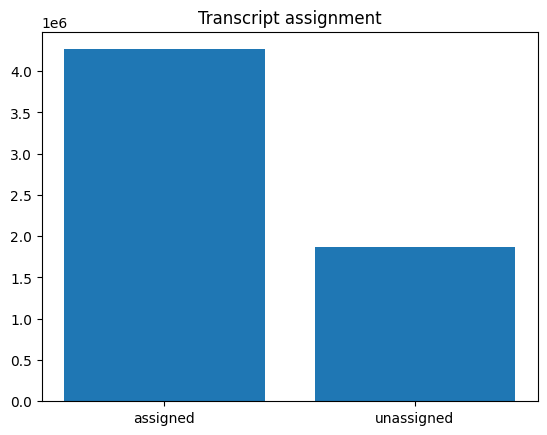

In [36]:
import matplotlib.pyplot as plt

assigned = trx_in_cells["cell_id_str"].notna().sum()
unassigned = trx_in_cells["cell_id_str"].isna().sum()

plt.figure()
plt.bar(["assigned", "unassigned"], [assigned, unassigned])
plt.title("Transcript assignment")
plt.show()

In [37]:
gene_counts = trx_hits.groupby("gene").size().sort_values(ascending=False).head(20)

plt.figure()
gene_counts.plot(kind="bar")
plt.ylabel("Transcript count")
plt.title("Top genes in ROI")
plt.xticks(rotation=45)
plt.show()

NameError: name 'trx_hits' is not defined

In [ ]:
trx_counts = (
    trx_in_cells.dropna(subset=["cell_id_str"])
    .groupby("cell_id_str")
    .size()
)

cell_hits_plot = cell_hits.copy()
cell_hits_plot["n_trx"] = cell_hits_plot["cell_id_str"].map(trx_counts).fillna(0)

fig, ax = plt.subplots(figsize=(6, 6))
cell_hits_plot.plot(
    column="n_trx",
    ax=ax,
    legend=True,
)
ax.set_title("Transcripts per cell (spatial)")
plt.show()

In [ ]:
plt.figure()
plt.hexbin(
    trx_hits_gdf.geometry.x,
    trx_hits_gdf.geometry.y,
    gridsize=50
)
plt.colorbar(label="Transcript density")
plt.title("Spatial transcript density")
plt.show()

In [ ]:
genes_per_cell = (
    trx_in_cells.dropna(subset=["cell_id_str"])
    .groupby("cell_id_str")["gene"]
    .nunique()
)

plt.figure()
plt.hist(genes_per_cell, bins=30)
plt.xlabel("Genes per cell")
plt.ylabel("Number of cells")
plt.title("Genes detected per cell")
plt.show()